# Task 4 - Email Spam Detection

This notebook builds a text classifier to separate spam messages from ham messages using TF-IDF features and machine learning models.

In [1]:
import os
import sys
import re
from pathlib import Path
import string
import zipfile
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')

## Load the dataset

In [2]:
data_dir = Path.cwd() / 'data'
if not data_dir.is_dir():
    data_dir = Path.cwd().parent / 'data'

candidate_files = [data_dir / 'spam.csv', data_dir / 'SMSSpamCollection', data_dir / 'sms_spam.csv']
source = next((file for file in candidate_files if file.is_file()), None)

if source is None:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
    zip_path = data_dir / 'smsspamcollection.zip'
    data_dir.mkdir(exist_ok=True)
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    with open(zip_path, 'wb') as file:
        file.write(response.content)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extract('SMSSpamCollection', data_dir)
    source = data_dir / 'SMSSpamCollection'

try:
    df = pd.read_csv(source, sep='\t', names=['label', 'message'])
except Exception:
    df = pd.read_csv(source, encoding='latin-1')
    if {'v1', 'v2'}.issubset(df.columns):
        df = df.rename(columns={'v1': 'label', 'v2': 'message'})[['label', 'message']]

print('Loaded from:', source)
df.head()

Loaded from: c:\Users\Angad\OIBSIP\data\SMSSpamCollection


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'] = df['label'].str.lower().str.strip()
df['message'] = df['message'].astype(str)

class_counts = df['label'].value_counts().rename_axis('label').reset_index(name='count')
class_counts['percentage'] = class_counts['count'] / len(df) * 100
class_counts

,label,count,percentage
0,ham,4825,86.593683
1,spam,747,13.406317


C:\Users\Angad\AppData\Local\Temp\ipykernel_1864\234167422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x='label', y='count', palette='Set2')


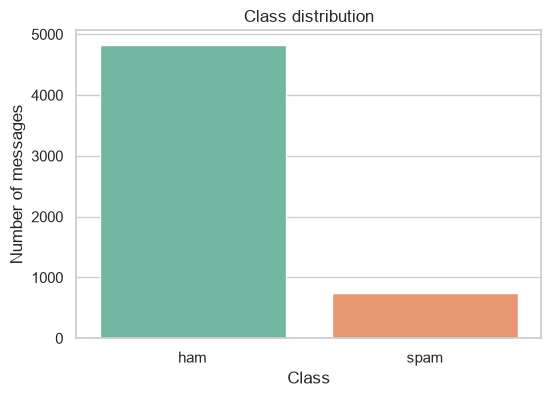

In [4]:
plt.figure(figsize=(6, 4))
sns.barplot(data=class_counts, x='label', y='count', palette='Set2')
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Number of messages')
plt.show()

## Text preprocessing

The cleaning function lowercases text, removes punctuation/numbers, removes common English stopwords, and joins the remaining words back into a sentence.

In [5]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', ' ', text)
    words = [word for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


## TF-IDF explanation

TF-IDF means Term Frequency-Inverse Document Frequency. It gives more weight to words that appear often in a message but are not common across every message. That helps the model focus on words that are more useful for classification.

## Train and evaluate models

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC()
}

rows = []
fitted_models = {}
for name, model in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, pos_label='spam'),
        'Recall': recall_score(y_test, preds, pos_label='spam'),
        'F1': f1_score(y_test, preds, pos_label='spam')
    })
    fitted_models[name] = pipe

results = pd.DataFrame(rows).sort_values('F1', ascending=False)
results

,Model,Accuracy,Precision,Recall,F1
2,Linear SVM,0.983857,0.978102,0.899329,0.937063
1,Logistic Regression,0.967713,1.000000,0.758389,0.862595
0,Multinomial Naive Bayes,0.965022,1.000000,0.738255,0.849421


Best model: Linear SVM
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



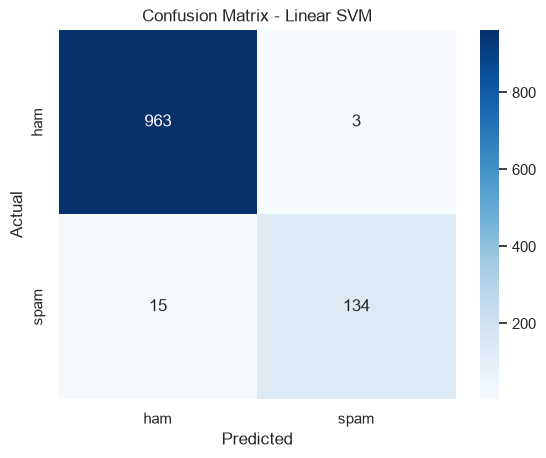

In [7]:
best_name = results.iloc[0]['Model']
best_model = fitted_models[best_name]
best_preds = best_model.predict(X_test)

print('Best model:', best_name)
print(classification_report(y_test, best_preds))

labels = ['ham', 'spam']
cm = confusion_matrix(y_test, best_preds, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Why recall matters

Recall is important because it measures how many real spam messages the model catches. If recall is too low, many spam messages reach the inbox. Precision also matters because we do not want real messages marked as spam, but spam filters usually need strong recall first.

Using WordCloud from: c:\Users\Angad\anaconda3\python.exe


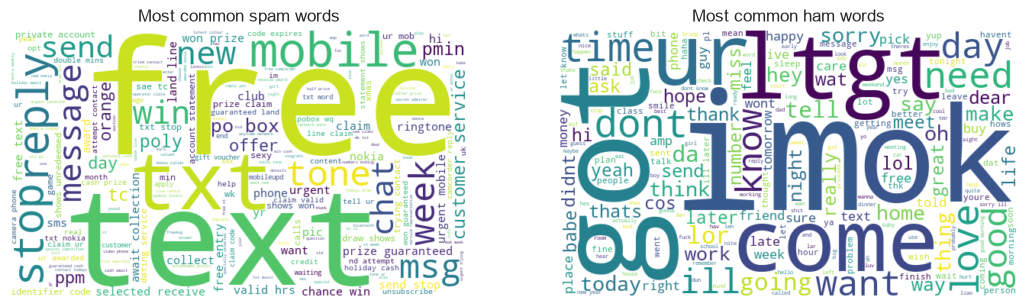

In [8]:
from wordcloud import WordCloud

print(f'Using WordCloud from: {sys.executable}')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, label in zip(axes, ['spam', 'ham']):
    text = ' '.join(df.loc[df['label'] == label, 'clean_message'])
    wc = WordCloud(width=600, height=350, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Most common {label} words')
    ax.axis('off')
plt.show()